In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
import abel
 

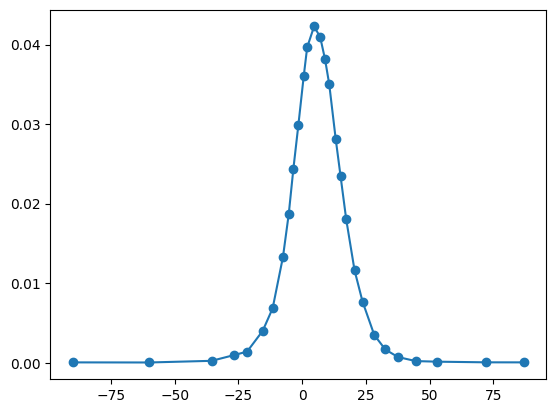

In [2]:
# read data from csv file as numpy array
data = np.loadtxt('q5_bulk_theta_orientation_borzsonyi.csv', delimiter=',', skiprows=1)
angles = data[:, 0]  # first column is angles
hist = data[:, 1]  # second column is histogram values
plt.plot(angles, hist, '-o', label='orientation distribution raw')

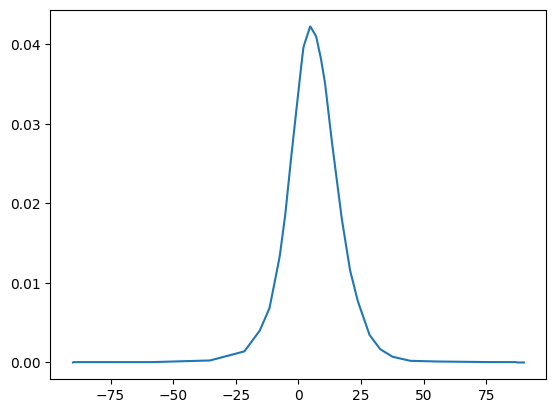

In [3]:
# 4. Interpolate to a uniform grid
num_points = 600
theta_uniform = np.linspace(-90, 90, num_points)
interp_func = interp1d(angles, hist, kind='linear', bounds_error=False, fill_value=0)
hist_uniform = interp_func(theta_uniform)
plt.plot(theta_uniform, hist_uniform, label='orientation distribution interpolated')

In [4]:
# find the circular mean of the angles distribution

theta_d = np.atan2(np.sum(np.sin(np.radians(theta_uniform)) * hist_uniform),
                     np.sum(np.cos(np.radians(theta_uniform)) * hist_uniform))

theta_d = np.degrees(theta_d)  # convert to degrees
print(f'Circular mean of the angles distribution: {theta_d:.2f} degrees')

Circular mean of the angles distribution: 5.77 degrees


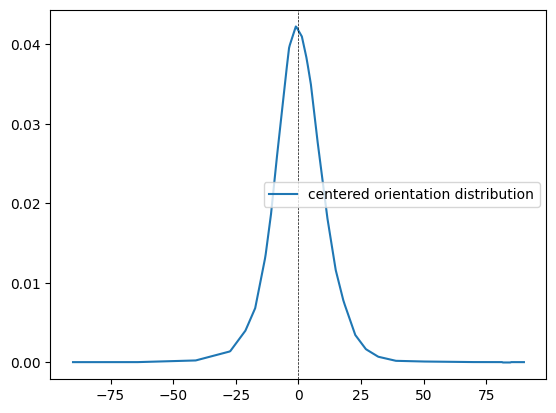

In [5]:
# find closest theta value to the circular mean
closest_index = np.argmin(np.abs(theta_uniform - theta_d))
closest_theta = theta_uniform[closest_index]
middle_index = num_points // 2

hist_centered = np.roll(hist_uniform, -closest_index + middle_index)
plt.plot(theta_uniform, hist_centered, label='centered orientation distribution')
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.legend()

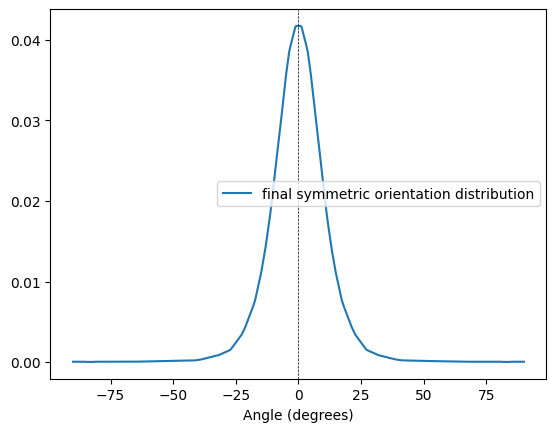

In [6]:
#make histogram symmetric

hist_sym = 0.5 * (hist_centered + np.flip(hist_centered))
plt.plot(theta_uniform, hist_sym, label='final symmetric orientation distribution')
plt.xlabel('Angle (degrees)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
plt.legend()


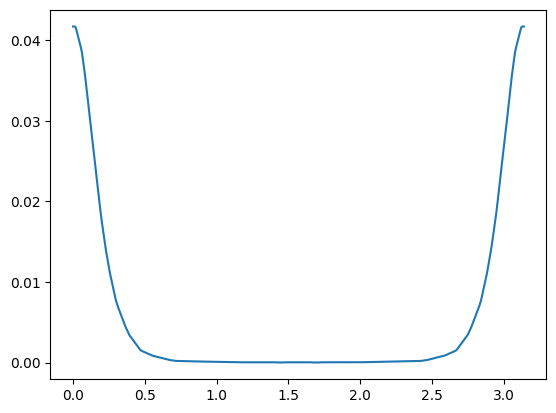

In [7]:
g_0_pi2 = hist_sym[:num_points // 2][::-1]
g_pi2_pi = np.flip(g_0_pi2.copy())
g_0_pi = np.concatenate((g_0_pi2, g_pi2_pi))

theta_2d = np.linspace(0, np.pi, num_points)
plt.plot(theta_2d, g_0_pi, label='g(0, pi)')

In [8]:
m = 40 #number of coefficients for fourier series
l = 40 #number of coefficients for legendre series

#extend g_0_pi to a full period
g_0_pi_full = np.concatenate((g_0_pi, g_0_pi[::-1]))
theta_full = np.linspace(0, 2 * np.pi, len(g_0_pi_full), endpoint=False)

g_0_pi_full /= np.trapezoid(g_0_pi_full, theta_full)  # normalize the function

# calculate the Fourier coefficients
T_vec = np.zeros(m) 
T_vec[0] = np.trapezoid(g_0_pi_full, theta_full) / (2 * np.pi)
for i in range(1,m):
    T_vec[i] = np.trapezoid(g_0_pi_full * np.cos(i * theta_full), theta_full) 

#set to zero T_vec when it is odd
# T_vec[1::2] = 0

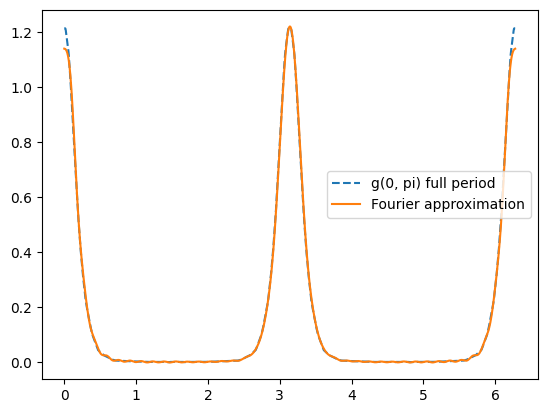

In [9]:
# plot for visualization of approximation

g_0_pi_full_approx = np.zeros_like(theta_full)
g_0_pi_full_approx += T_vec[0]  # constant term
for i in range(1, m):
    g_0_pi_full_approx += T_vec[i] * np.cos(i * theta_full)/np.pi


plt.plot(theta_full, g_0_pi_full, '--', label='g(0, pi) full period')
plt.plot(theta_full, g_0_pi_full_approx, '-', label='Fourier approximation')
plt.legend()

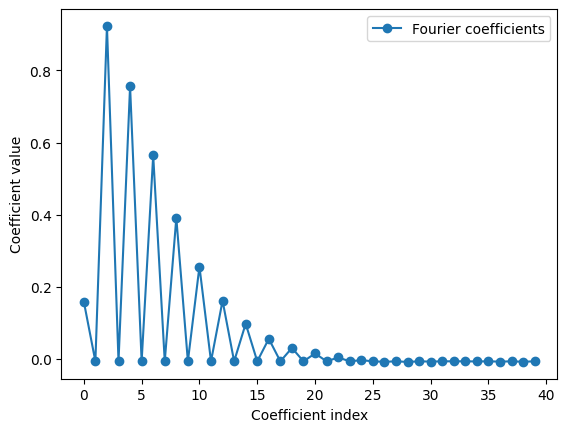

In [10]:
plt.plot(T_vec, 'o-', label='Fourier coefficients')
plt.xlabel('Coefficient index')
plt.ylabel('Coefficient value')
plt.legend()


Text(0.5, 1.0, 'Matrix L for Fourier coefficients')

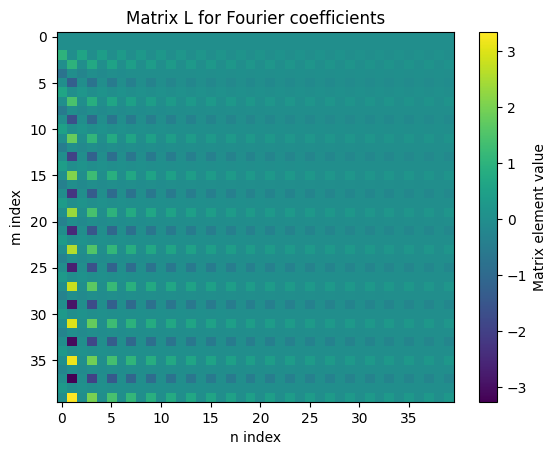

In [11]:
from scipy.special import binom

# matrix elements
n = m
L = np.zeros((m, n))

for i in range(1,m):
    prefactor = 1/2**i
    for j in range(n):
        sum = 0
        for k in range(0, int(np.floor(i/2))):
            end_factor = (1 + (-1)**(i+j)) / (1 + i + j - 2*k)
            sum += (-1)**k * binom(i, k) * binom(2*i-2*k, i) * end_factor

        
        L[i, j] = prefactor * sum

#plot the L_matrix
plt.figure()
plt.imshow(L, cmap='viridis', aspect='auto')
plt.colorbar(label='Matrix element value')
plt.xlabel('n index')
plt.ylabel('m index')
plt.title('Matrix L for Fourier coefficients')


Text(0, 0.5, 'l index')

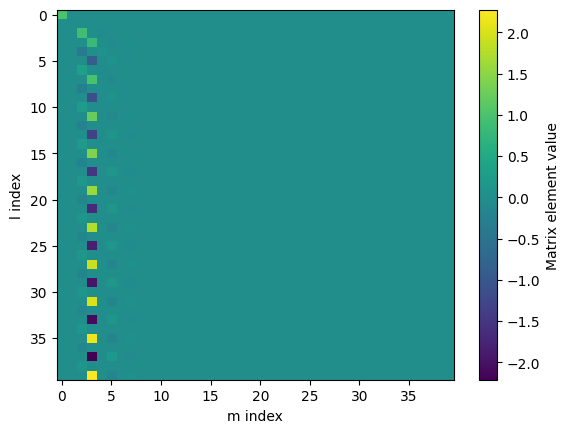

In [12]:
from scipy.special import factorial, gamma

# construct the matrix inversion to get legendre polynomials

P_inv = np.zeros((l, m))
for i in range(1, m):
    prefactor = i / (2 *np.sqrt(np.pi))
    for j in range(l):
        sum = 0
        for k in range(0, int(np.floor(i/2))):
            first_term = (-1)**k * 2**(i-2*k)
            second_term = (2 + i - 2*k)
            factorial_term = factorial(i-k-1) / (factorial(i) * factorial(i-2*k))
            end_term = gamma( (i - 2*k+3)/2 ) / gamma( (i -2*k+4)/2 )
            sum +=  first_term * second_term * factorial_term * end_term * L[j, int(i-2*k)]
        P_inv[j, i] = prefactor*  sum
P_inv[:, 0] = 0 # first column is zero m=0
P_inv[0, 0] = 1 

plt.figure()
plt.imshow(P_inv, cmap='viridis', aspect='auto')
plt.colorbar(label='Matrix element value')
plt.xlabel('m index')
plt.ylabel('l index')



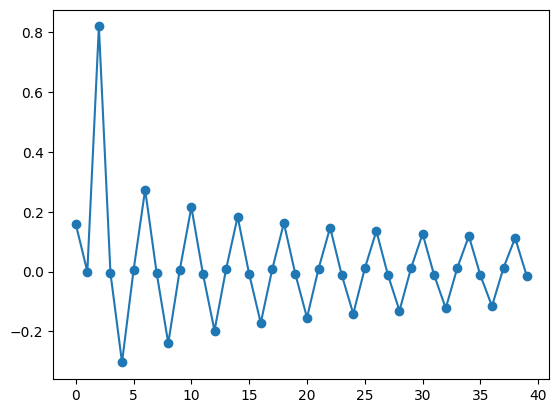

In [13]:
# find legendre coefficients
P_vec = P_inv @ T_vec

# for i in range(len(P_vec)):
#     if (P_vec[i]) < 1e-10:  # threshold to zero out small coefficients
#         P_vec[i] = 0

plt.plot(P_vec, 'o-', label='Legendre coefficients')



Text(0.5, 0, 'Angle (radians)')

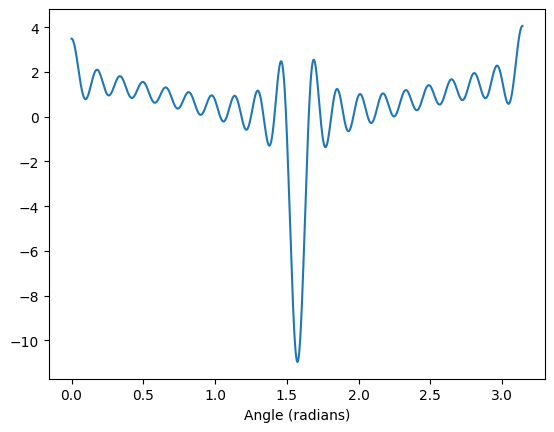

In [14]:
#reconstruct the function using Legendre coefficients

from scipy.special import legendre


theta_3d = np.linspace(0, np.pi, len(theta_full))

f_3d = np.zeros_like(theta_3d)
for i in range(l):
    f_3d += (2*i+1)/2 * P_vec[i] *  legendre(i)(np.cos(theta_3d))
    # f_3d += 1legendre(i)(np.cos(theta_3d))
    # print(f'Legendre polynomial of order {i}:')

# f_3d /= np.trapezoid(2*np.pi * f_3d*np.sin(theta_3d), theta_3d)  # normalize the function
# plot the reconstructed function
plt.figure()
plt.plot(theta_3d, f_3d, label='Reconstructed function using Legendre coefficients')
plt.xlabel('Angle (radians)')

In [15]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import root_scalar

# P2 Legendre polynomial
def P2(x):
    return 0.5 * (3 * x**2 - 1)

# Normalization Z(α)
def Z(U_fit):
    integrand = lambda theta: np.exp(U_fit * 1/2*(3*np.cos(theta)**2-1)) * np.sin(theta)
    return quad(integrand, 0, np.pi/2)[0]

# S(α)
def S_alpha(U_fit):
    norm = Z(U_fit)
    integrand = lambda theta: np.exp(U_fit * 1/2*(3*np.cos(theta)**2-1)) * P2(np.cos(theta)) * np.sin(theta)
    return quad(integrand, 0, np.pi/2)[0] / norm

# Find α such that S(α) = S_target
def find_U(S_target):
    def objective(U_fit):
        return S_alpha(U_fit) - S_target
    sol = root_scalar(objective, bracket=[0.01, 50], method='brentq')  # Positive α only
    return sol.root if sol.converged else None

# Reconstruct f(θ)
def f_theta(theta, U_fit):
    norm = Z(U_fit)
    return np.exp(U_fit * 1/2*(3*np.cos(theta)**2-1)) / norm


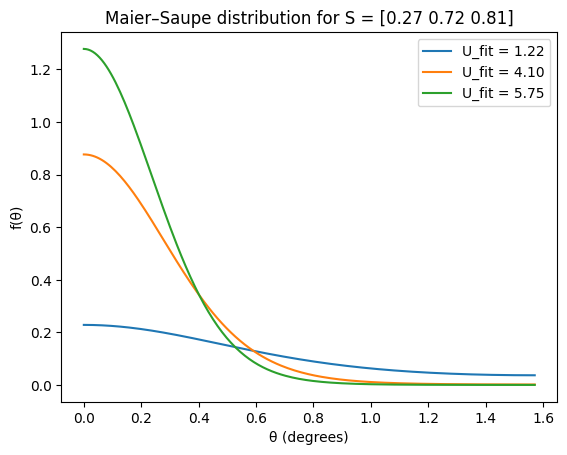

In [16]:
S_given = np.array([0.27, 0.72, 0.81])
density = np.array([0.495, 0.5, 0.48])
alphas = np.array([2.0, 3.3, 5.0])


U_fit = np.zeros(len(alphas))  # Initialize U_fit for each alpha
theta_vals = np.linspace(0, np.pi/2, 200)


for i, alpha in enumerate(alphas):
    S_target = S_given[i]  # Target S value for this alpha
    U_fit[i] = find_U(S_target)
    
    # Plot the distribution
    f_vals = f_theta(theta_vals, U_fit[i])
    f_vals /= 4*np.pi*np.trapezoid( f_vals * np.sin(theta_vals), theta_vals)  

    plt.plot(theta_vals , f_vals, label=f"U_fit = {U_fit[i]:.2f}")
plt.xlabel("θ (degrees)")
plt.ylabel("f(θ)")
plt.title(f"Maier–Saupe distribution for S = {S_given}")
plt.legend()
plt.show()


Predicted U for alpha 2.0: 0.9281
Fitted U for alpha 2.0: 1.2152
Predicted U for alpha 3.3: 2.7401
Fitted U for alpha 3.3: 4.1048
Predicted U for alpha 5.0: 4.7897
Fitted U for alpha 5.0: 5.7470
Ratio of U_fit to U_predicted: [1.30933415 1.49801491 1.19986489]


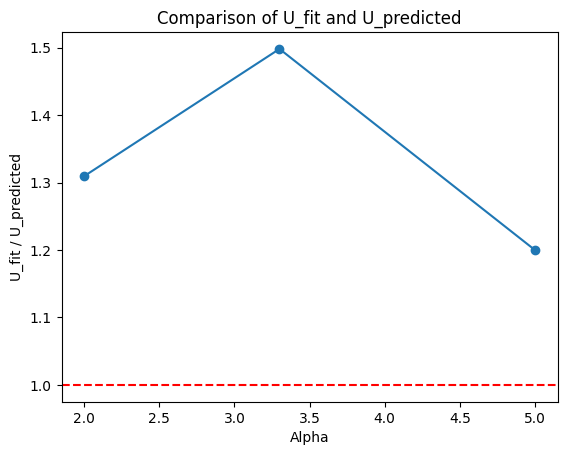

In [17]:
def excluded_volume_rod(alpha):
    second_coeff_A_complete = -5 /32 *np.pi *  (8*alpha / np.pi +2/alpha)
    # second_coeff_A_complete = 16 * alpha / (3*np.pi) 
    second_coeff_B_complete = 5/4
    second_coeff_C_complete = 0.385*8/np.pi

    return (second_coeff_A_complete +second_coeff_B_complete + second_coeff_C_complete)

def correction_density(phi):
    return phi*(1-3/4*phi) / (1-phi)**2

U_predicted = np.zeros(len(alphas))  # Initialize U_predicted for each alpha
for i, alpha in enumerate(alphas):
    volume_fraction = density[i]  
    U_predicted[i] = - excluded_volume_rod(alpha) * correction_density(volume_fraction)
    print(f"Predicted U for alpha {alpha}: {U_predicted[i]:.4f}")
    print(f"Fitted U for alpha {alpha}: {U_fit[i]:.4f}")

plt.plot(alphas, U_fit/U_predicted, 'o-', label='U_fit / U_predicted')
plt.xlabel('Alpha')
plt.ylabel('U_fit / U_predicted')
plt.title('Comparison of U_fit and U_predicted')
plt.axhline(1, color='red', linestyle='--', label='U_fit = U_predicted')

print(f"Ratio of U_fit to U_predicted: {U_fit / U_predicted}")


In [20]:
import numpy as np
from scipy.integrate import quad

# Define your known function f(theta)
def f(theta):
    return np.exp(S_given[2] * (3 * np.cos(theta)**2 - 1) / 2 * U_fit[2])  # Example function, adjust as needed


# Define the g(theta_2D) function
def g(theta_2D):
    cos_theta = np.cos(theta_2D)
    abs_cos_theta = np.abs(cos_theta)

    # Integrand
    def integrand(t):
        if cos_theta**2 - t**2 <= 0:
            return 0  # Avoid domain error
        return t * f(np.arccos(t)) / np.sqrt(cos_theta**2 - t**2)

    # Numerical integration from 0 to cos(theta_2D)
    integral, _ = quad(integrand, 0, cos_theta)

    # Compute g
    return (1 / (np.pi * abs_cos_theta)) * integral


In [21]:
phi = np.linspace(0, np.pi/2, 300)
g_2d = np.zeros_like(phi)

for i, theta in enumerate(phi):
    g_2d[i] = g(theta)

Text(0, 0.5, '$g(\\theta)$')

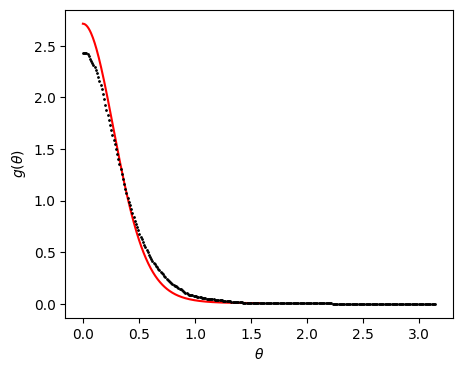

In [35]:
g_2d = g_2d / np.trapezoid(g_2d, phi)  # Normalize the function

phi_plot = np.linspace(-np.pi, np.pi, 2*len(phi))
g_2d_plot = np.concatenate((g_2d[::-1], g_2d))

g_2d_plot /= np.trapezoid(g_2d_plot, phi_plot)  # Normalize the function for plotting


theta_experiment = np.linspace(0, np.pi, num_points//2)
hist_half = hist_sym[num_points//2:]
hist_half /= np.trapezoid(hist_half, theta_experiment)  # Normalize the histogram

hist_plot = np.concatenate((hist_half[::-1], hist_half))
theta_experiment_full = np.linspace(-np.pi, np.pi, num_points)
hist_plot /= np.trapezoid(hist_plot, theta_experiment_full)  # Normalize the histogram for plotting


# plt.plot(theta_uniform, hist_sym, label='final symmetric orientation distribution')

plt.figure(figsize=(5, 4))  
# plt.plot(phi_plot, g_2d_plot, 'red', label='reconstructed')
# plt.plot(theta_experiment, hist_plot, 'ko', markersize=1, label='measured')
plt.plot(phi, g_2d, 'red', label='reconstructed')
plt.plot(theta_experiment, hist_half, 'ko', markersize=1, label='measured')
plt.xlabel('$\\theta$')
plt.ylabel('$g(\\theta)$')

